In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import lineStyles


In [2]:
from autogluon.tabular import TabularPredictor, TabularDataset

C:\Users\muhammadraiyansani\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
insurance_df=pd.read_csv("insurance.csv")

**disini kita menggunakan groupby seperti di spark untuk mengurutkan sesuatu berdasarkan groupby yang mana hasilnya hanya bisa ditampilkan jika kita menambahkan perintah agg seperti count,mean,max**

disini ditambahkan numeric only karena dataframe berisi beberapa kolom object

In [3]:
insurance_df.groupby(by=['region']).mean(numeric_only=True)

,age,bmi,children,charges
region,,,,
northeast,39.268519,29.173503,1.046296,13406.384516
northwest,39.196923,29.199785,1.147692,12417.575374
southeast,38.939560,33.355989,1.049451,14735.411438
southwest,39.455385,30.596615,1.141538,12346.937377


In [4]:
insurance_df.groupby(by=['age'])['charges'].mean()

age
18     7086.217556
19     9747.909335
20    10159.697736
21     4730.464330
22    10012.932802
23    12419.820040
24    10648.015962
25     9838.365311
26     6133.825309
27    12184.701721
28     9069.187564
29    10430.158727
30    12719.110358
31    10196.980573
32     9220.300291
33    12351.532987
34    11613.528121
35    11307.182031
36    12204.476138
37    18019.911877
38     8102.733674
39    11778.242945
40    11772.251310
41     9653.745650
42    13061.038669
43    19267.278653
44    15859.396587
45    14830.199856
46    14342.590639
47    17653.999593
48    14632.500445
49    12696.006264
50    15663.003301
51    15682.255867
52    18256.269719
53    16020.930755
54    18758.546475
55    16164.545488
56    15025.515837
57    16447.185250
58    13878.928112
59    18895.869532
60    21979.418507
61    22024.457609
62    19163.856573
63    19884.998461
64    23275.530837
Name: charges, dtype: float64

In [5]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
insurance_df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [8]:
insurance_df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [5]:
insurance_df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: >

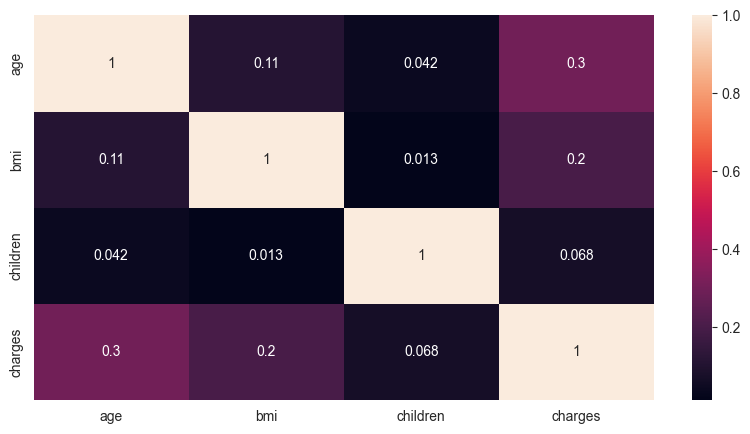

In [11]:
plt.figure(figsize = (10,5))
sns.heatmap(insurance_df.corr(numeric_only=True), annot=True)

sekarang kita akan memisahkan data, tetapi langsung dibagi dua data dari dataframe insurance tanpa harus membagi x dan y dahulu

In [4]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(insurance_df,test_size=0.2,random_state=42)

In [13]:
df_test

,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180
...,...,...,...,...,...,...,...
109,63,male,35.090,0,yes,southeast,47055.53210
575,58,female,27.170,0,no,northwest,12222.89830
535,38,male,28.025,1,no,northeast,6067.12675
543,54,female,47.410,0,yes,southeast,63770.42801


In [14]:
df_train

,age,sex,bmi,children,smoker,region,charges
560,46,female,19.950,2,no,northwest,9193.83850
1285,47,female,24.320,0,no,northeast,8534.67180
1142,52,female,24.860,0,no,southeast,27117.99378
969,39,female,34.320,5,no,southeast,8596.82780
486,54,female,21.470,3,no,northwest,12475.35130
...,...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast,4561.18850
1130,39,female,23.870,5,no,southeast,8582.30230
1294,58,male,25.175,0,no,northeast,11931.12525
860,37,female,47.600,2,yes,southwest,46113.51100


**disini kita akan melatih mesin autogluon yang akan melatih 11 model ML untuk mendapatkan hasil terbaik dengan menggunakan data validation dan bagging data 8 kali**

In [5]:
predictor=TabularPredictor(label='charges',problem_type='regression',eval_metric='r2').fit(train_data=df_train,time_limit=200,presets="best_quality")

No path specified. Models will be saved in: "AutogluonModels\ag-20251119_004924"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.7
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          22
Memory Avail:       5.23 GB / 15.61 GB (33.5%)
Disk Space Avail:   262.63 GB / 475.92 GB (55.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of 

(_ray_fit pid=22936) [1000]	valid_set's l2: 2.66428e+07	valid_set's r2: 0.805565
(_ray_fit pid=22936) [2000]	valid_set's l2: 2.60546e+07	valid_set's r2: 0.809857


(_ray_fit pid=22936) 	Ran out of time, early stopping on iteration 2658. Best iteration is:
(_ray_fit pid=22936) 	[2624]	valid_set's l2: 2.56238e+07	valid_set's r2: 0.813001
(_dystack pid=27256) 	0.8518	 = Validation score   (r2)
(_dystack pid=27256) 	4.3s	 = Training   runtime
(_dystack pid=27256) 	0.05s	 = Validation runtime
(_dystack pid=27256) Fitting model: WeightedEnsemble_L3 ... Training model for up to 31.14s of the -9.05s of remaining time.
(_dystack pid=27256) 	Ensemble Weights: {'LightGBMXT_BAG_L2': 1.0}
(_dystack pid=27256) 	0.8518	 = Validation score   (r2)
(_dystack pid=27256) 	0.01s	 = Training   runtime
(_dystack pid=27256) 	0.0s	 = Validation runtime
(_dystack pid=27256) AutoGluon training complete, total runtime = 40.36s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 1260.1 rows/s (119 batch size)
(_dystack pid=27256) Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...
(_dystack pid=27256) Tabula

In [6]:
predictor.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                    model  score_val eval_metric  pred_time_val   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0     WeightedEnsemble_L2   0.856617          r2       0.648460  83.534924                0.000000           0.179309            2       True          8
1         CatBoost_BAG_L1   0.855671          r2       0.063703  49.144632                0.063703          49.144632            1       True          4
2       LightGBMXT_BAG_L1   0.850508          r2       0.050889   5.599992                0.050889           5.599992            1       True          1
3         LightGBM_BAG_L1   0.847752          r2       0.047522   5.017453                0.047522           5.017453            1       True          2
4  NeuralNetFastAI_BAG_L1   0.841506          r2       0.128573  18.192185                0.128573          18.192185            1       True          6
5          XGBoost_B

C:\Users\muhammadraiyansani\miniconda3\Lib\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


{'model_types': {'LightGBMXT_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L1': 'StackerEnsembleModel_XT',
  'NeuralNetFastAI_BAG_L1': 'StackerEnsembleModel_NNFastAiTabular',
  'XGBoost_BAG_L1': 'StackerEnsembleModel_XGBoost',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT_BAG_L1': 0.8505080700229694,
  'LightGBM_BAG_L1': 0.8477517795636971,
  'RandomForestMSE_BAG_L1': 0.8299080252509099,
  'CatBoost_BAG_L1': 0.8556705253922032,
  'ExtraTreesMSE_BAG_L1': 0.8342047027251699,
  'NeuralNetFastAI_BAG_L1': 0.8415057113553045,
  'XGBoost_BAG_L1': 0.8413807166266184,
  'WeightedEnsemble_L2': 0.8566165981762001},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT_BAG_L1': ['LightGBMXT_BAG_L1'],
  'LightGBM_BAG_L1': ['LightGBM_BAG_L1'],
  'RandomForestMSE_BAG_L1': ['RandomF

disini kita akan melihat laporan dari autogluon predictor dengan tampilan dataframe


In [7]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.856617,r2,0.648460,83.534924,0.000000,0.179309,2,True,8
1,CatBoost_BAG_L1,0.855671,r2,0.063703,49.144632,0.063703,49.144632,1,True,4
2,LightGBMXT_BAG_L1,0.850508,r2,0.050889,5.599992,0.050889,5.599992,1,True,1
3,LightGBM_BAG_L1,0.847752,r2,0.047522,5.017453,0.047522,5.017453,1,True,2
4,NeuralNetFastAI_BAG_L1,0.841506,r2,0.128573,18.192185,0.128573,18.192185,1,True,6
5,XGBoost_BAG_L1,0.841381,r2,0.083324,4.074693,0.083324,4.074693,1,True,7
6,ExtraTreesMSE_BAG_L1,0.834205,r2,0.273857,1.114358,0.273857,1.114358,1,True,5
7,RandomForestMSE_BAG_L1,0.829908,r2,0.274449,1.326659,0.274449,1.326659,1,True,3


plt.xstick disini berfungsi untuk memutar teks dari x label menjadi 90 derajat, karena jika tidak teks akan bertabrakan

In [13]:
df=predictor.leaderboard()
df[df['stack_level']==1]

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
4,CatBoost_BAG_L1,0.855671,r2,0.021709,49.444943,0.021709,49.444943,1,True,4
6,LightGBMXT_BAG_L1,0.850508,r2,0.025431,1.373227,0.025431,1.373227,1,True,1
7,LightGBM_BAG_L1,0.847752,r2,0.013056,2.185573,0.013056,2.185573,1,True,2
8,NeuralNetTorch_BAG_L1,0.844661,r2,0.055581,12.756657,0.055581,12.756657,1,True,8
10,NeuralNetFastAI_BAG_L1,0.841506,r2,0.088177,7.573529,0.088177,7.573529,1,True,6
11,XGBoost_BAG_L1,0.841381,r2,0.032722,2.176090,0.032722,2.176090,1,True,7
12,ExtraTreesMSE_BAG_L1,0.834205,r2,0.082789,0.447152,0.082789,0.447152,1,True,5
13,RandomForestMSE_BAG_L1,0.829908,r2,0.089985,0.568597,0.089985,0.568597,1,True,3


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'WeightedEnsemble_L2'),
  Text(1, 0, 'CatBoost_BAG_L1'),
  Text(2, 0, 'LightGBMXT_BAG_L1'),
  Text(3, 0, 'NeuralNetTorch_BAG_L1'),
  Text(4, 0, 'LightGBM_BAG_L1'),
  Text(5, 0, 'NeuralNetFastAI_BAG_L1'),
  Text(6, 0, 'XGBoost_BAG_L1'),
  Text(7, 0, 'ExtraTreesMSE_BAG_L1'),
  Text(8, 0, 'RandomForestMSE_BAG_L1'),
  Text(9, 0, 'LightGBMLarge_BAG_L1')])

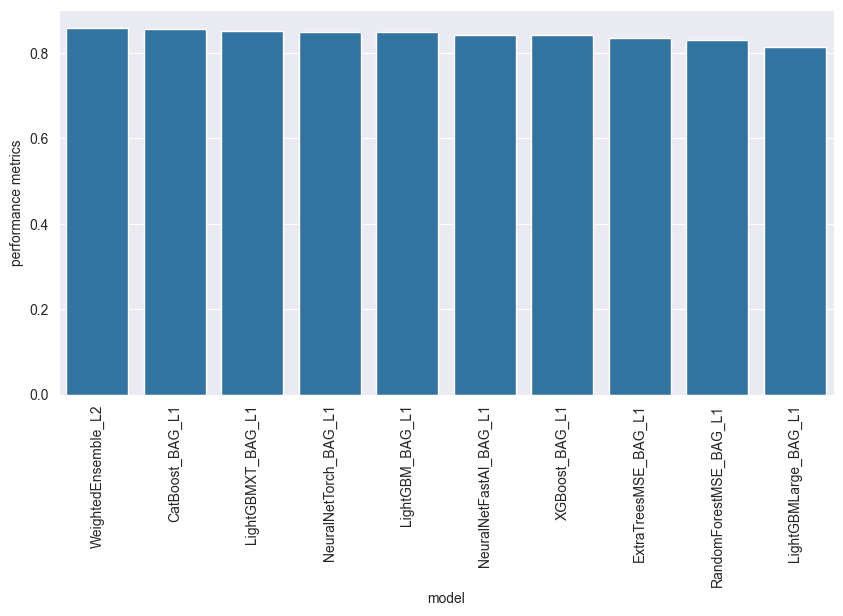

In [11]:
plt.figure(figsize = (10,5))
sns.barplot(x='model',y='score_val',data=predictor.leaderboard())
plt.ylabel('performance metrics')
plt.xlabel('model')
plt.xticks(rotation=90)

disini kita bisa mengevaluasi model

In [8]:
predictor.evaluate(df_test)

{'r2': 0.8821427330965188,
 'root_mean_squared_error': np.float64(-4277.521616994218),
 'mean_squared_error': -18297191.18385283,
 'mean_absolute_error': -2402.0273932652754,
 'pearsonr': 0.9397931473845581,
 'median_absolute_error': -1532.05613046875}

disini kita hanya melihat kasus error yang paling jauh, abs adalah nilai absolut yang akan menghilangkan nilai minus

In [12]:
# 1. Buat DataFrame perbandingan
df_test_copy = df_test.copy()
df_test_copy['prediksi'] = predictor.predict(df_test)
df_test_copy['error'] = abs(df_test_copy['charges'] - df_test_copy['prediksi'])

# 2. Urutkan dari error terbesar
print("=== 5 KASUS PALING SULIT DITEBAK ===")
print(df_test_copy.sort_values('error', ascending=False).head(5))

=== 5 KASUS PALING SULIT DITEBAK ===
      age     sex     bmi  children smoker     region      charges  \
806    40  female  41.420         1     no  northwest  28476.73499   
430    19    male  33.100         0     no  southwest  23082.95533   
599    52  female  37.525         2     no  northwest  33471.97189   
1039   19    male  27.265         2     no  northwest  22493.65964   
543    54  female  47.410         0    yes  southeast  63770.42801   

          prediksi         error  
806    7261.909180  21214.825810  
430    2358.466553  20724.488777  
599   13032.702148  20439.269742  
1039   5003.090820  17490.568820  
543   46561.949219  17208.478791  


disini saya membandingkan antara nilai asli,nilai prediksi dan error , disini nilai error di absolutkan untuk menghilangkan nilai minus agar kita bisa mengetahui berapa selisih antara prediksi dengan nilai asli

In [9]:
# menilai kinerja model
# Pilih 5 set data uji dan hasilkan prediksi
y_pred = predictor.predict(df_test)
perbandingan=pd.DataFrame({"data_prediksi":y_pred,"data_asli":df_test['charges'],"error":abs(y_pred-df_test['charges'])})
perbandingan.head(5)

,data_prediksi,data_asli,error
764,10726.802734,9095.06825,1631.734484
887,6007.232910,5272.17580,735.057110
890,27789.447266,29330.98315,1541.535884
1293,10285.441406,9301.89355,983.547856
259,33671.140625,33750.29180,79.151175


Text(0, 0.5, 'prediksi')

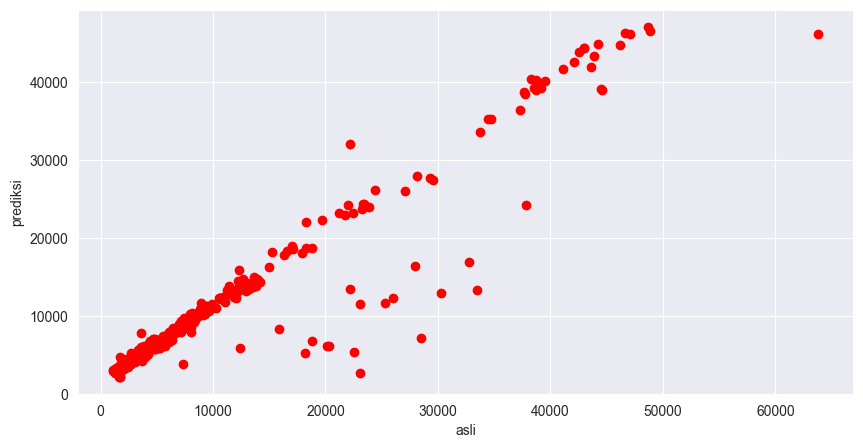

In [11]:
plt.figure(figsize = (10,5))
plt.scatter(perbandingan['data_asli'],perbandingan['data_prediksi'],color='red')
plt.xlabel('asli')
plt.ylabel('prediksi')

In [24]:
4255.505499631543/insurance_df['charges'].mean()*100

np.float64(32.0675967547009)

**jadi disini dibuat uji coba dengan mengganti preset dan time limit**

 * rmse 32.5317335238713 preset high 240
* rmse  32.26349372101222 preset medium 240(55 detik)
* rmse 32.93196028129041 preset high 240
* rmse 32.26349372101222 preset medium 100(55 detik)
* rmse  32.38707027177882 preset good 300
* rmse  32.26349372101222 preset optimize 300(17 detik)
* rmse  32.26349372101222 preset optimize 60( 17 detik)
* rmse  32.0675967547009 preset best 200


ini adalah hasil preset rmse, semakin kecil rmse semakin baik

In [12]:
predictor=TabularPredictor(label='charges',problem_type='regression',eval_metric='root_mean_squared_error').fit(train_data=df_train,time_limit=200,presets="high_quality")


No path specified. Models will be saved in: "AutogluonModels\ag-20251120_014423"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.7
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          22
Memory Avail:       4.32 GB / 15.61 GB (27.7%)
Disk Space Avail:   261.71 GB / 475.92 GB (55.0%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True

(_ray_fit pid=7992) [1000]	valid_set's rmse: 5052.58
(_ray_fit pid=7992) [2000]	valid_set's rmse: 4920.45
(_ray_fit pid=7992) [3000]	valid_set's rmse: 4857.64
(_ray_fit pid=7992) [4000]	valid_set's rmse: 4802.06
(_ray_fit pid=7992) [5000]	valid_set's rmse: 4769.41
(_ray_fit pid=7992) [6000]	valid_set's rmse: 4748.42


(_ray_fit pid=7992) 	Ran out of time, early stopping on iteration 6915. Best iteration is:
(_ray_fit pid=7992) 	[6876]	valid_set's rmse: 4722.75
(_ray_fit pid=6272) 	Ran out of time, early stopping on iteration 71. [repeated 3x across cluster]
(_dystack pid=14668) 	-4576.071	 = Validation score   (-root_mean_squared_error)
(_dystack pid=14668) 	7.03s	 = Training   runtime
(_dystack pid=14668) 	0.11s	 = Validation runtime
(_dystack pid=14668) Fitting model: WeightedEnsemble_L3 ... Training model for up to 41.94s of the -9.33s of remaining time.
(_dystack pid=14668) 	Ensemble Weights: {'CatBoost_BAG_L1': 0.444, 'LightGBMXT_BAG_L2': 0.444, 'RandomForestMSE_BAG_L1': 0.111}
(_dystack pid=14668) 	-4523.5661	 = Validation score   (-root_mean_squared_error)
(_dystack pid=14668) 	0.01s	 = Training   runtime
(_dystack pid=14668) 	0.0s	 = Validation runtime
(_dystack pid=14668) AutoGluon training complete, total runtime = 51.38s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput

In [13]:
predictor.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                          model    score_val              eval_metric  pred_time_val   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0           WeightedEnsemble_L2 -4527.499323  root_mean_squared_error       0.252165  86.341562                0.000000           0.004192            2      False         11
1               CatBoost_BAG_L1 -4564.164307  root_mean_squared_error       0.009540  40.005731                0.009540          40.005731            1      False          4
2          CatBoost_r177_BAG_L1 -4597.590321  root_mean_squared_error       0.033069   6.905123                0.033069           6.905123            1      False         10
3             LightGBMXT_BAG_L1 -4645.073918  root_mean_squared_error       0.018273   0.775193                0.018273           0.775193            1      False          1
4         NeuralNetTorch_BAG_L1 -4657.489080  root_mean_squared_erro

C:\Users\muhammadraiyansani\miniconda3\Lib\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


{'model_types': {'LightGBMXT_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L1': 'StackerEnsembleModel_XT',
  'NeuralNetFastAI_BAG_L1': 'StackerEnsembleModel_NNFastAiTabular',
  'XGBoost_BAG_L1': 'StackerEnsembleModel_XGBoost',
  'NeuralNetTorch_BAG_L1': 'StackerEnsembleModel_TabularNeuralNetTorch',
  'LightGBMLarge_BAG_L1': 'StackerEnsembleModel_LGB',
  'CatBoost_r177_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'LightGBMXT_BAG_L1_FULL': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1_FULL': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1_FULL': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1_FULL': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L1_FULL': 'StackerEnsembleModel_XT',
  'NeuralNetFastAI_BAG_L1_FULL': 'StackerEnsembleModel_NNFastAiTabular',
  'XGBo

In [14]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4527.499323,root_mean_squared_error,0.252165,86.341562,0.000000,0.004192,2,False,11
1,CatBoost_BAG_L1,-4564.164307,root_mean_squared_error,0.009540,40.005731,0.009540,40.005731,1,False,4
2,CatBoost_r177_BAG_L1,-4597.590321,root_mean_squared_error,0.033069,6.905123,0.033069,6.905123,1,False,10
3,LightGBMXT_BAG_L1,-4645.073918,root_mean_squared_error,0.018273,0.775193,0.018273,0.775193,1,False,1
4,NeuralNetTorch_BAG_L1,-4657.489080,root_mean_squared_error,0.028411,32.303988,0.028411,32.303988,1,False,8
5,LightGBM_BAG_L1,-4687.700618,root_mean_squared_error,0.009862,2.208403,0.009862,2.208403,1,False,2
6,NeuralNetFastAI_BAG_L1,-4782.891880,root_mean_squared_error,0.077190,9.292053,0.077190,9.292053,1,False,6
7,XGBoost_BAG_L1,-4784.777495,root_mean_squared_error,0.037504,1.995669,0.037504,1.995669,1,False,7
8,ExtraTreesMSE_BAG_L1,-4891.813136,root_mean_squared_error,0.085222,0.484337,0.085222,0.484337,1,True,5
9,RandomForestMSE_BAG_L1,-4954.794726,root_mean_squared_error,0.089658,0.531526,0.089658,0.531526,1,True,3


In [8]:
predictor.evaluate(df_test)

{'root_mean_squared_error': np.float64(-4281.501854265656),
 'mean_squared_error': -18331258.128080256,
 'mean_absolute_error': -2199.930631989622,
 'r2': 0.8819232984905154,
 'pearsonr': 0.9393176903505073,
 'median_absolute_error': -1166.7047222656256}

In [10]:
evaluation=predictor.evaluate(df_test)
rmse=abs(evaluation['root_mean_squared_error'])
rmse

np.float64(4281.501854265656)

In [11]:
rmse/insurance_df['charges'].mean()*100

np.float64(32.26349372101222)

disini kita akan visualisasi dengan rmse, semakin besar nilainya semakin payah

Text(0.5, 0, 'model')

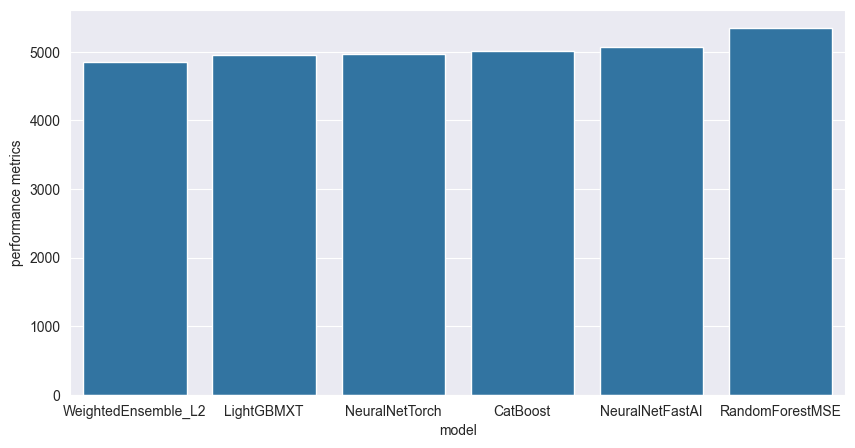

In [58]:
visual=predictor.leaderboard()
visual['score_val']=abs(visual['score_val'])
plt.figure(figsize = (10,5))
sns.barplot(x='model',y='score_val',data=visual)
plt.ylabel('performance metrics')
plt.xlabel('model')

**jadi setiap kita membuat model baru, maka autogluon akan menyimpan log model di folder project, nantinya jika kita akan masuk kembali ke project maka kita tidak usah membuat model baru, cukup load model sebelumnya, cara load model sebelumnya adalah dengan "predictor = TabularPredictor.load("_nama_path_folder_"), karena nantinya di folder autogluon akan membuat nama acak, maka kita bisa tambahkan "predictor = TabularPredictor(path=path_model).fit(...)" agar nama folder sesuai dengan keinginan kita**